In [3]:
! pip install pandas
! pip install numpy
! pip install scikit-learn
! pip install matplotlib
! pip install prophet
! pip install plotly


   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.1 MB 1.2 MB/s eta 0:00:10
   ---- ----------------------------------- 1.3/12.1 MB 1.7 MB/s eta 0:00:07
   ------ --------------------------------- 1.8/12.1 MB 2.0 MB/s eta 0:00:06
   ------- -------------------------------- 2.4/12.1 MB 2.0 MB/s eta 0:00:05
   ---------- ----------------------------- 3.1/12.1 MB 2.3 MB/s eta 0:00:04
   ------------ --------------------------- 3.9/12.1 MB 2.5 MB/s eta 0:00:04
   --------------- ------------------------ 4.7/12.1 MB 2.6 MB/s eta 0:00:03
   ------------------ --------------------- 5.5/12.1 MB 2.7 MB/s eta 0:00:03
   --------------------- ------------------ 6.6/12.1 MB 2.9 MB/s eta 0:00:02
   ----------------------- ---------------- 7.1/12.1 MB 2.9 MB/s eta 0:00:02
   -----------------

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from prophet import Prophet

print("All libraries installed successfully")

All libraries installed successfully


In [6]:
path = r"C:\Users\avila\Downloads\layoff dataset\layoffs.csv"
df = pd.read_csv(path)
df.head(7)

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Livspace,"Bengaluru, Non-U.S.",1000.0,2/20/2026,0.12,Consumer,https://inc42.com/buzz/livspace-fires-1000-emp...,Series F,482.0,India,2/22/2026
1,Lucid Motors,SF Bay Area,NaN,2/20/2026,0.12,Transportation,https://techcrunch.com/2026/02/20/lucid-motors...,Post-IPO,8300.0,United States,2/22/2026
2,Cyberark,Boston,500.0,2/17/2026,0.12,Security,https://www.calcalistech.com/ctechnews/article...,Acquired,1700.0,United States,2/18/2026
3,Huawei,"Tel Aviv, Non-U.S.",50.0,2/15/2026,NaN,Hardware,https://www.calcalistech.com/ctechnews/article...,Unknown,NaN,Israel,2/18/2026
4,Axonius,New York City,40.0,2/15/2026,0.04,Security,https://www.calcalistech.com/ctechnews/article...,Series E,865.0,United States,2/18/2026
5,Clari,SF Bay Area,76.0,2/12/2026,NaN,Sales,https://www.bizjournals.com/sanjose/news/2026/...,Acquired,496.0,United States,2/18/2026
6,Glossier,New York City,50.0,2/11/2026,0.33,Retail,https://www.businessoffashion.com/news/cosmeti...,Series E,266.0,United States,2/13/2026


In [7]:
df['date'] = pd.to_datetime(df['date'])

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.dropna(subset=['total_laid_off'], inplace=True)

In [10]:
df.to_csv(path, index=False)
print("Cleaned successfully")

Cleaned successfully


In [11]:
df.isnull().sum()

company                  0
location                 0
total_laid_off           0
date                     0
percentage_laid_off    887
industry                 1
source                   0
stage                    1
funds_raised           285
country                  1
date_added               0
dtype: int64

In [12]:
df['percentage_laid_off'] = df['percentage_laid_off'].fillna(
    df['percentage_laid_off'].median()
)

In [13]:
df['funds_raised'] = df['funds_raised'].fillna(0)
df['industry'] = df['industry'].fillna(
    df['industry'].mode()[0]
)
df['country'] = df['country'].fillna(
    df['country'].mode()[0]
)
df.isnull().sum()


company                0
location               0
total_laid_off         0
date                   0
percentage_laid_off    0
industry               0
source                 0
stage                  1
funds_raised           0
country                0
date_added             0
dtype: int64

In [14]:
df['stage'] = df['stage'].fillna(
    df['stage'].mode()[0]
)
df.isnull().sum()


company                0
location               0
total_laid_off         0
date                   0
percentage_laid_off    0
industry               0
source                 0
stage                  0
funds_raised           0
country                0
date_added             0
dtype: int64

In [19]:
df.to_csv(r"C:\Users\avila\Downloads\cleaned_layoff.csv", index=False)
print("Cleaned successfully")

Cleaned successfully


In [20]:
path1 = r"C:\Users\avila\Downloads\cleaned_layoff.csv"
df = pd.read_csv(path1)

In [21]:
df.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Livspace,"Bengaluru, Non-U.S.",1000.0,2026-02-20,0.12,Consumer,https://inc42.com/buzz/livspace-fires-1000-emp...,Series F,482.0,India,2/22/2026
1,Cyberark,Boston,500.0,2026-02-17,0.12,Security,https://www.calcalistech.com/ctechnews/article...,Acquired,1700.0,United States,2/18/2026
2,Huawei,"Tel Aviv, Non-U.S.",50.0,2026-02-15,0.15,Hardware,https://www.calcalistech.com/ctechnews/article...,Unknown,0.0,Israel,2/18/2026
3,Axonius,New York City,40.0,2026-02-15,0.04,Security,https://www.calcalistech.com/ctechnews/article...,Series E,865.0,United States,2/18/2026
4,Clari,SF Bay Area,76.0,2026-02-12,0.15,Sales,https://www.bizjournals.com/sanjose/news/2026/...,Acquired,496.0,United States,2/18/2026


In [22]:
# layoff frequency per company
layoff_frequency = df.groupby('company').size()

df['layoff_frequency'] = df['company'].map(layoff_frequency)

In [23]:
# Layoff intensity score
df['layoff_intensity'] = df['total_laid_off'] * df['percentage_laid_off']

In [24]:
# Funding risk indicator
df['funding_risk'] = df['total_laid_off'] / (df['funds_raised'] + 1)

In [25]:
industry_risk = df.groupby('industry')['percentage_laid_off'].mean()
df['industry_risk_score'] = df['industry'].map(industry_risk)

In [26]:
# Risk Score
df['risk_score'] = (
    0.4 * df['percentage_laid_off'] +
    0.3 * df['layoff_frequency'] +
    0.3 * df['industry_risk_score']
)

In [27]:
#Risk category
def risk_category(score):
    
    if score < 20:
        return "Low Risk"
    
    elif score < 50:
        return "Medium Risk"
    
    else:
        return "High Risk"

df['risk_category'] = df['risk_score'].apply(risk_category)

In [28]:
df.to_csv("final_layoff_risk_dataset.csv", index=False)

In [29]:
df[['company','risk_score','risk_category']].head(10)

,company,risk_score,risk_category
0,Livspace,1.007743,Low Risk
1,Cyberark,0.391962,Low Risk
2,Huawei,0.397811,Low Risk
3,Axonius,0.659962,Low Risk
4,Clari,1.006958,Low Risk
5,Glossier,1.394909,Low Risk
6,Workday,0.962320,Low Risk
7,Rewire,0.419208,Low Risk
8,Zillow,1.328062,Low Risk
9,Zipcar,0.721614,Low Risk


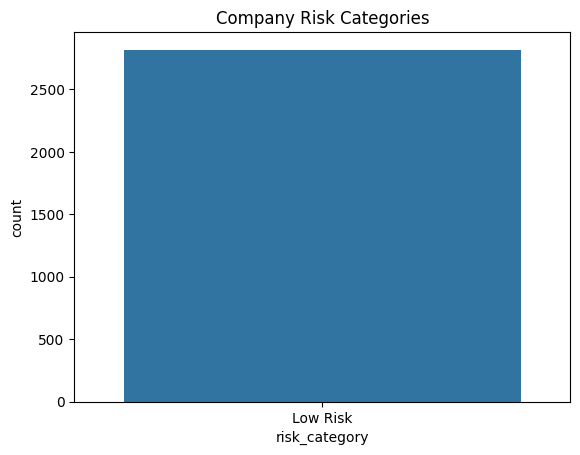

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='risk_category', data=df)

plt.title("Company Risk Categories")

plt.show()

In [31]:
df.to_csv(r"C:\Users\avila\Downloads\final_layoff_risk_dataset.csv", index=False)